# Normallik Varsayımının İncelenmesi

## Shapiro - Wilk

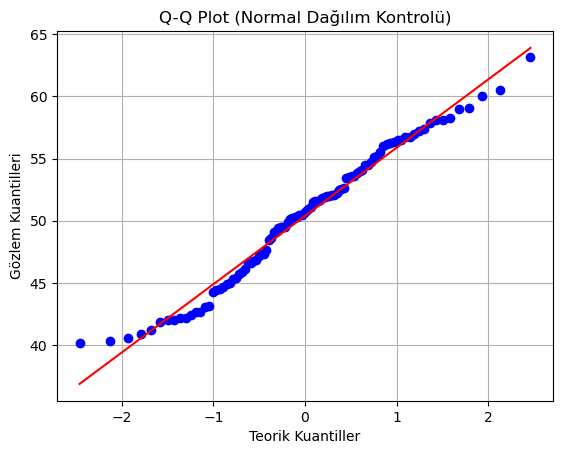

Shapiro-Wilk Testi
Test İstatistiği: 0.9772797668362199
p-değeri: 0.0814291548730323
Sonuç: Veri normal dağılıma uygundur (H0 reddedilemez).


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def qq_plot_kontrol(veri):
    """
    Verilen veri seti için:
    - Q-Q plot çizer
    - Shapiro-Wilk normalite testi yapar
    - Sonucu yorumlar
    """
    
    veri = np.array(veri)
    
    # --- Q-Q Plot ---
    plt.figure()
    stats.probplot(veri, dist="norm", plot=plt)
    plt.title("Q-Q Plot (Normal Dağılım Kontrolü)")
    plt.xlabel("Teorik Kuantiller")
    plt.ylabel("Gözlem Kuantilleri")
    plt.grid(True)
    plt.show()
    
    # --- Shapiro-Wilk Testi ---
    stat, p_degeri = stats.shapiro(veri)
    
    print("Shapiro-Wilk Testi")
    print("Test İstatistiği:", stat)
    print("p-değeri:", p_degeri)
    
    if p_degeri > 0.05:
        print("Sonuç: Veri normal dağılıma uygundur (H0 reddedilemez).")
    else:
        print("Sonuç: Veri normal dağılmıyor (H0 reddedilir).")
        

# ---------------------------------------------------
# Örnek kullanım:

# Normal dağılıma yakın veri
veri = np.random.normal(loc=50, scale=5, size=100)

qq_plot_kontrol(veri)

## Kolmogrov - Simigrov

In [7]:
def ks_test_normal_kontrol(veri):
    """
    Kolmogorov-Smirnov testi ile
    normal dağılım varsayımını kontrol eder.
    """
    
    veri = np.array(veri)
    
    # --- Standardizasyon ---
    ortalama = np.mean(veri)
    std = np.std(veri, ddof=1)
    veri_standard = (veri - ortalama) / std
    
    # --- K-S Testi ---
    D, p_degeri = stats.kstest(veri_standard, 'norm')
    
    print("Kolmogorov-Smirnov Testi Sonuçları")
    print("D istatistiği:", D)
    print("p-değeri:", p_degeri)
    
    if p_degeri > 0.05:
        print("Sonuç: Veri normal dağılıma uygundur (H0 reddedilemez).")
    else:
        print("Sonuç: Veri normal dağılmıyor (H0 reddedilir).")
        
    return D, p_degeri


# --------------------------------------------------
# Örnek kullanım

veri = np.random.normal(loc=50, scale=5, size=100)

ks_test_normal_kontrol(veri)

Kolmogorov-Smirnov Testi Sonuçları
D istatistiği: 0.05991451465657427
p-değeri: 0.8440875888098753
Sonuç: Veri normal dağılıma uygundur (H0 reddedilemez).


(np.float64(0.05991451465657427), np.float64(0.8440875888098753))

# Varyans Homojenliği Varyamının İncelenmesi

## F-Testi

In [17]:
def iki_orneklem_f_testi(veri1, veri2, alpha=0.05):
    """
    İki bağımsız örneklem için
    varyans homojenliği F testi yapar.
    """
    
    veri1 = np.array(veri1)
    veri2 = np.array(veri2)
    
    # Örnek varyansları (ddof=1 -> örnek varyansı)
    var1 = np.var(veri1, ddof=1)
    var2 = np.var(veri2, ddof=1)
    
    # Büyük varyansı üste yaz
    if var1 > var2:
        F = var1 / var2
        df1 = len(veri1) - 1
        df2 = len(veri2) - 1
    else:
        F = var2 / var1
        df1 = len(veri2) - 1
        df2 = len(veri1) - 1
    
    # İki kuyruklu p-değeri
    p_degeri = 2 * (1 - stats.f.cdf(F, df1, df2))
    
    print("F Testi Sonuçları")
    print("------------------")
    print("F istatistiği:", F)
    print("Serbestlik dereceleri:", df1, ",", df2)
    print("p-değeri:", p_degeri)
    
    if p_degeri > alpha:
        print("Sonuç: Varyanslar homojendir (H0 reddedilemez).")
    else:
        print("Sonuç: Varyanslar farklıdır (H0 reddedilir).")
    
    return F, p_degeri

In [20]:
np.random.seed(42)

grup1 = np.random.normal(50, 5, 30)
grup2 = np.random.normal(50, 7, 30)

iki_orneklem_f_testi(grup1, grup2)

F Testi Sonuçları
------------------
F istatistiği: 2.097778127809
Serbestlik dereceleri: 29 , 29
p-değeri: 0.05046454941257439
Sonuç: Varyanslar homojendir (H0 reddedilemez).


(np.float64(2.097778127809), np.float64(0.05046454941257439))

## ikiden fazla örneklem 

### Levente Testi

In [18]:
def levene_testi(veri1, veri2, alpha=0.05, merkez='median'):
    """
    Levene testi ile varyans homojenliği kontrolü
    
    merkez:
        'mean'   -> klasik Levene
        'median' -> Brown-Forsythe (daha sağlam)
        'trimmed' -> kırpılmış ortalama
    """
    
    veri1 = np.array(veri1)
    veri2 = np.array(veri2)
    
    stat, p_degeri = stats.levene(veri1, veri2, center=merkez)
    
    print("Levene Testi Sonuçları")
    print("-----------------------")
    print("Test istatistiği:", stat)
    print("p-değeri:", p_degeri)
    
    if p_degeri > alpha:
        print("Sonuç: Varyanslar homojendir (H0 reddedilemez).")
    else:
        print("Sonuç: Varyanslar farklıdır (H0 reddedilir).")
    
    return stat, p_degeri

In [19]:
np.random.seed(42)

grup1 = np.random.normal(50, 5, 30)
grup2 = np.random.normal(50, 8, 30)

levene_testi(grup1, grup2)

Levene Testi Sonuçları
-----------------------
Test istatistiği: 8.145010407097184
p-değeri: 0.005978154565145821
Sonuç: Varyanslar farklıdır (H0 reddedilir).


(np.float64(8.145010407097184), np.float64(0.005978154565145821))

### Bartlett Testi

In [21]:
def bartlett_testi(*gruplar, alpha=0.05):
    """
    Bartlett testi ile varyans homojenliği kontrolü.
    İki veya daha fazla grup alabilir.
    """
    
    gruplar = [np.array(g) for g in gruplar]
    
    stat, p_degeri = stats.bartlett(*gruplar)
    
    print("Bartlett Testi Sonuçları")
    print("--------------------------")
    print("Test istatistiği:", stat)
    print("p-değeri:", p_degeri)
    
    if p_degeri > alpha:
        print("Sonuç: Varyanslar homojendir (H0 reddedilemez).")
    else:
        print("Sonuç: Varyanslar farklıdır (H0 reddedilir).")
    
    return stat, p_degeri

In [22]:
np.random.seed(42)

grup1 = np.random.normal(50, 5, 30)
grup2 = np.random.normal(50, 8, 30)

bartlett_testi(grup1, grup2)

Bartlett Testi Sonuçları
--------------------------
Test istatistiği: 6.953539621146411
p-değeri: 0.008365355641355503
Sonuç: Varyanslar farklıdır (H0 reddedilir).


(np.float64(6.953539621146411), np.float64(0.008365355641355503))